In [1]:
# Fix numpy version conflict with Colab's default environment
!pip install numpy==1.26.4 --force-reinstall -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-co

In [2]:
# Setup — run this every time you open a new Colab session
import os

if not os.path.exists('/content/tabddpm-hospital-readmission-prediction'):
    !git clone https://github.com/Jiten-Bhalavat/tabddpm-hospital-readmission-prediction.git

os.chdir('/content/tabddpm-hospital-readmission-prediction')
!pip install -r requirements.txt -q

print("Environment setup complete")

Cloning into 'tabddpm-hospital-readmission-prediction'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 156 (delta 47), reused 145 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 22.13 MiB | 10.70 MiB/s, done.
Resolving deltas: 100% (47/47), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 112.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.2 MB/

In [3]:
# Import all required libraries for evaluation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from ctgan import CTGAN

RANDOM_STATE = 42

# Load the processed train/test splits prepared by Rohith
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

print("Data loaded successfully!")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  Minority class in train : {(y_train == 1).sum()} patients")
print(f"  Minority class in test  : {(y_test == 1).sum()} patients")

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7fb0219fe5c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


Data loaded successfully!
  X_train shape : (79472, 42)
  X_test shape  : (19868, 42)
  Minority class in train : 9051 patients
  Minority class in test  : 2263 patients


In [4]:
# ── Baseline: Train XGBoost on raw imbalanced data with no augmentation ──
# This is our benchmark. The model will perform poorly on the minority class
# because it has never seen enough readmission examples to learn from.

baseline_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
baseline_model.fit(X_train, y_train)

y_pred_base  = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

f1_base  = f1_score(y_test, y_pred_base, pos_label=1)
auc_base = roc_auc_score(y_test, y_proba_base)
cm_base  = confusion_matrix(y_test, y_pred_base)

print("=" * 50)
print("  BASELINE RESULTS (no augmentation)")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_base:.4f}")
print(f"  ROC-AUC                    : {auc_base:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Not Readmitted', 'Readmitted <30']))

  BASELINE RESULTS (no augmentation)
  F1 Score  (minority class) : 0.0548
  ROC-AUC                    : 0.6581

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.45      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.67      0.51      0.50     19868
  weighted avg       0.84      0.89      0.84     19868



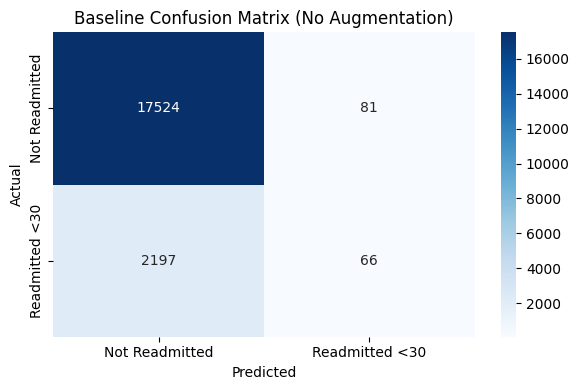

Saved baseline_results.json and baseline_confusion_matrix.png


In [5]:
# Save baseline metrics and confusion matrix plot to results folder

os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

baseline_metrics = {
    'method'   : 'baseline_no_augmentation',
    'f1_score' : round(f1_base, 4),
    'roc_auc'  : round(auc_base, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_base[0][0]),
        'false_positives' : int(cm_base[0][1]),
        'false_negatives' : int(cm_base[1][0]),
        'true_positives'  : int(cm_base[1][1])
    }
}

with open('results/metrics/baseline_results.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)

# Confusion matrix plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Readmitted', 'Readmitted <30'],
            yticklabels=['Not Readmitted', 'Readmitted <30'])
plt.title('Baseline Confusion Matrix (No Augmentation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/figures/baseline_confusion_matrix.png', dpi=150)
plt.show()

print("Saved baseline_results.json and baseline_confusion_matrix.png")

In [6]:
# ── SMOTE: Synthetic Minority Over-sampling Technique ──
# SMOTE generates fake minority patients by averaging between real ones.
# Applied to training data only — the test set is never touched.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE applied!")
print(f"  Before — Minority: {(y_train == 1).sum()}, Majority: {(y_train == 0).sum()}")
print(f"  After  — Minority: {(y_train_smote == 1).sum()}, Majority: {(y_train_smote == 0).sum()}")

smote_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote  = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

f1_smote  = f1_score(y_test, y_pred_smote, pos_label=1)
auc_smote = roc_auc_score(y_test, y_proba_smote)
cm_smote  = confusion_matrix(y_test, y_pred_smote)

print()
print("=" * 50)
print("  SMOTE RESULTS")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_smote:.4f}")
print(f"  ROC-AUC                    : {auc_smote:.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=['Not Readmitted', 'Readmitted <30']))

SMOTE applied!
  Before — Minority: 9051, Majority: 70421
  After  — Minority: 70421, Majority: 70421

  SMOTE RESULTS
  F1 Score  (minority class) : 0.0525
  ROC-AUC                    : 0.6525

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.46      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.67      0.51      0.50     19868
  weighted avg       0.84      0.89      0.84     19868



In [7]:
# Save SMOTE metrics to results folder

smote_metrics = {
    'method'   : 'smote',
    'f1_score' : round(f1_smote, 4),
    'roc_auc'  : round(auc_smote, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_smote[0][0]),
        'false_positives' : int(cm_smote[0][1]),
        'false_negatives' : int(cm_smote[1][0]),
        'true_positives'  : int(cm_smote[1][1])
    }
}

with open('results/metrics/smote_results.json', 'w') as f:
    json.dump(smote_metrics, f, indent=2)

print("Saved smote_results.json")

Saved smote_results.json


In [9]:
# ── CTGAN: Conditional Tabular GAN ──
# CTGAN learns the distribution of real minority patients and generates
# synthetic ones. Trained on minority class rows only.
# Note: This will take 2-5 minutes to train.

X_train_minority = X_train[y_train == 1].copy()

print(f"Training CTGAN on {len(X_train_minority)} minority class patients...")

ctgan_model = CTGAN(epochs=100, verbose=False)
ctgan_model.fit(X_train_minority)

print("CTGAN training complete!")

Training CTGAN on 9051 minority class patients...
CTGAN training complete!


In [10]:
# Generate synthetic minority patients and evaluate CTGAN augmented classifier

n_to_generate = len(X_train_minority)
synthetic_patients = ctgan_model.sample(n_to_generate)
synthetic_patients = synthetic_patients[X_train.columns]

# Combine real training data with synthetic minority patients
X_train_ctgan = pd.concat([X_train, synthetic_patients], ignore_index=True)
y_train_ctgan = pd.concat([y_train, pd.Series([1] * n_to_generate)], ignore_index=True)

print(f"Generated {n_to_generate} synthetic minority patients")
print(f"  Original training size : {len(X_train)}")
print(f"  Augmented training size: {len(X_train_ctgan)}")

ctgan_clf = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False
)
ctgan_clf.fit(X_train_ctgan, y_train_ctgan)

y_pred_ctgan  = ctgan_clf.predict(X_test)
y_proba_ctgan = ctgan_clf.predict_proba(X_test)[:, 1]

f1_ctgan  = f1_score(y_test, y_pred_ctgan, pos_label=1)
auc_ctgan = roc_auc_score(y_test, y_proba_ctgan)
cm_ctgan  = confusion_matrix(y_test, y_pred_ctgan)

print()
print("=" * 50)
print("  CTGAN RESULTS")
print("=" * 50)
print(f"  F1 Score  (minority class) : {f1_ctgan:.4f}")
print(f"  ROC-AUC                    : {auc_ctgan:.4f}")
print()
print(classification_report(y_test, y_pred_ctgan, target_names=['Not Readmitted', 'Readmitted <30']))

Generated 9051 synthetic minority patients
  Original training size : 79472
  Augmented training size: 88523

  CTGAN RESULTS
  F1 Score  (minority class) : 0.0478
  ROC-AUC                    : 0.6630

                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     17605
Readmitted <30       0.47      0.03      0.05      2263

      accuracy                           0.89     19868
     macro avg       0.68      0.51      0.49     19868
  weighted avg       0.84      0.89      0.84     19868



In [11]:
# Save CTGAN metrics to results folder

ctgan_metrics = {
    'method'   : 'ctgan',
    'f1_score' : round(f1_ctgan, 4),
    'roc_auc'  : round(auc_ctgan, 4),
    'confusion_matrix': {
        'true_negatives'  : int(cm_ctgan[0][0]),
        'false_positives' : int(cm_ctgan[0][1]),
        'false_negatives' : int(cm_ctgan[1][0]),
        'true_positives'  : int(cm_ctgan[1][1])
    }
}

with open('results/metrics/ctgan_results.json', 'w') as f:
    json.dump(ctgan_metrics, f, indent=2)

print("Saved ctgan_results.json")

Saved ctgan_results.json


In [12]:
# ── TabDDPM: Tabular Denoising Diffusion Probabilistic Model ──
# Uses synthetic patients generated by Simi's trained TabDDPM model.
# Evaluated at three augmentation ratios: 50%, 100%, and 200%.

ratios = ['50pct', '100pct', '200pct']
tabddpm_results = {}

for ratio in ratios:
    print(f"Running TabDDPM — {ratio} augmentation...")

    X_train_aug = pd.read_csv(f'/content/X_train_aug_{ratio}.csv')
    y_train_aug = pd.read_csv(f'/content/y_train_aug_{ratio}.csv').squeeze()

    clf = XGBClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )
    clf.fit(X_train_aug, y_train_aug)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, y_proba)
    cm  = confusion_matrix(y_test, y_pred)

    tabddpm_results[ratio] = {
        'method'   : f'tabddpm_{ratio}',
        'f1_score' : round(f1, 4),
        'roc_auc'  : round(auc, 4),
        'confusion_matrix': {
            'true_negatives'  : int(cm[0][0]),
            'false_positives' : int(cm[0][1]),
            'false_negatives' : int(cm[1][0]),
            'true_positives'  : int(cm[1][1])
        }
    }

    print(f"  F1: {f1:.4f}  AUC: {auc:.4f}")

print()
print("=" * 50)
print("  TABDDPM SUMMARY")
print("=" * 50)
for ratio, res in tabddpm_results.items():
    print(f"  {ratio:8s} — F1: {res['f1_score']:.4f}  AUC: {res['roc_auc']:.4f}")

Running TabDDPM — 50pct augmentation...
  F1: 0.0405  AUC: 0.6588
Running TabDDPM — 100pct augmentation...
  F1: 0.0477  AUC: 0.6616
Running TabDDPM — 200pct augmentation...
  F1: 0.0421  AUC: 0.6584

  TABDDPM SUMMARY
  50pct    — F1: 0.0405  AUC: 0.6588
  100pct   — F1: 0.0477  AUC: 0.6616
  200pct   — F1: 0.0421  AUC: 0.6584


Saved tabddpm_50pct_results.json
Saved tabddpm_100pct_results.json
Saved tabddpm_200pct_results.json


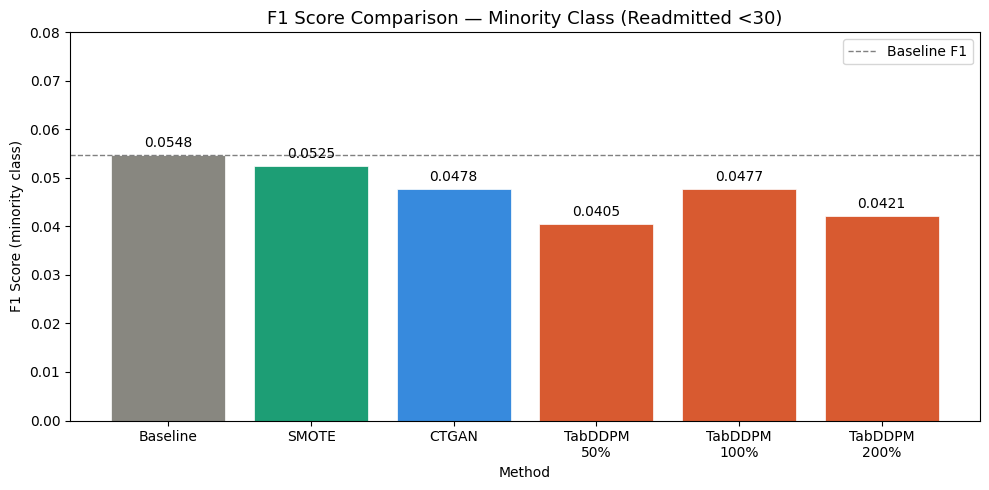

Saved final_comparison.png


In [13]:
# Save TabDDPM metrics and generate final comparison chart

for ratio, res in tabddpm_results.items():
    with open(f'results/metrics/tabddpm_{ratio}_results.json', 'w') as f:
        json.dump(res, f, indent=2)
    print(f"Saved tabddpm_{ratio}_results.json")

# Final comparison bar chart
methods  = ['Baseline', 'SMOTE', 'CTGAN', 'TabDDPM\n50%', 'TabDDPM\n100%', 'TabDDPM\n200%']
f1_scores = [
    f1_base, f1_smote, f1_ctgan,
    tabddpm_results['50pct']['f1_score'],
    tabddpm_results['100pct']['f1_score'],
    tabddpm_results['200pct']['f1_score']
]
colors = ['#888780', '#1D9E75', '#378ADD', '#D85A30', '#D85A30', '#D85A30']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, f1_scores, color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(y=f1_base, color='gray', linestyle='--', linewidth=1, label='Baseline F1')
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.title('F1 Score Comparison — Minority Class (Readmitted <30)', fontsize=13)
plt.ylabel('F1 Score (minority class)')
plt.xlabel('Method')
plt.ylim(0, 0.08)
plt.legend()
plt.tight_layout()
plt.savefig('results/figures/final_comparison.png', dpi=150)
plt.show()

print("Saved final_comparison.png")

In [14]:
# ── 5-Seed Experiment ──
# Every experiment is repeated 5 times with different random seeds.
# We report mean F1 ± std dev to ensure results are reliable and not lucky.

SEEDS = [42, 7, 13, 21, 99]
results_seeds = {
    'baseline'      : [],
    'smote'         : [],
    'ctgan'         : [],
    'tabddpm_50pct' : [],
    'tabddpm_100pct': [],
    'tabddpm_200pct': []
}

for seed in SEEDS:
    print(f"Running seed {seed}...")

    # Baseline
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_train, y_train)
    results_seeds['baseline'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # SMOTE
    smote = SMOTE(random_state=seed)
    X_sm, y_sm = smote.fit_resample(X_train, y_train)
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_sm, y_sm)
    results_seeds['smote'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # CTGAN
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_train_ctgan, y_train_ctgan)
    results_seeds['ctgan'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 50%
    X_aug = pd.read_csv('/content/X_train_aug_50pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_50pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_50pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 100%
    X_aug = pd.read_csv('/content/X_train_aug_100pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_100pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_100pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    # TabDDPM 200%
    X_aug = pd.read_csv('/content/X_train_aug_200pct.csv')
    y_aug = pd.read_csv('/content/y_train_aug_200pct.csv').squeeze()
    clf = XGBClassifier(n_estimators=100, random_state=seed, eval_metric='logloss', use_label_encoder=False)
    clf.fit(X_aug, y_aug)
    results_seeds['tabddpm_200pct'].append(f1_score(y_test, clf.predict(X_test), pos_label=1))

    print(f"  Seed {seed} done!")

print()
print("=" * 60)
print("  5-SEED RESULTS — Mean F1 ± Std Dev")
print("=" * 60)
for method, scores in results_seeds.items():
    mean = np.mean(scores)
    std  = np.std(scores)
    print(f"  {method:<20} F1: {mean:.4f} ± {std:.4f}")
print("=" * 60)

Running seed 42...
  Seed 42 done!
Running seed 7...
  Seed 7 done!
Running seed 13...
  Seed 13 done!
Running seed 21...
  Seed 21 done!
Running seed 99...
  Seed 99 done!

  5-SEED RESULTS — Mean F1 ± Std Dev
  baseline             F1: 0.0548 ± 0.0000
  smote                F1: 0.0524 ± 0.0052
  ctgan                F1: 0.0478 ± 0.0000
  tabddpm_50pct        F1: 0.0405 ± 0.0000
  tabddpm_100pct       F1: 0.0477 ± 0.0000
  tabddpm_200pct       F1: 0.0421 ± 0.0000


In [15]:
# Save 5-seed experiment results to results folder

seed_summary = {}
for method, scores in results_seeds.items():
    seed_summary[method] = {
        'f1_scores' : [round(s, 4) for s in scores],
        'mean_f1'   : round(np.mean(scores), 4),
        'std_f1'    : round(np.std(scores), 4),
        'seeds'     : SEEDS
    }

with open('results/metrics/5seed_results.json', 'w') as f:
    json.dump(seed_summary, f, indent=2)

print("Saved 5seed_results.json")

Saved 5seed_results.json


In [16]:
# ── Synthetic Only Honesty Test ──
# Train the classifier entirely on synthetic patients, test on real ones.
# If F1 is reasonable, synthetic data genuinely captured real patterns.

# CTGAN synthetic only
X_real_majority = X_train[y_train == 0].copy()
y_real_majority = y_train[y_train == 0].copy()

X_synth_only = pd.concat([X_real_majority, synthetic_patients], ignore_index=True)
y_synth_only = pd.concat([y_real_majority, pd.Series([1] * len(synthetic_patients))], ignore_index=True)

print(f"CTGAN synthetic-only training set: {len(X_synth_only)} rows")
print(f"  Majority (real): {(y_synth_only == 0).sum()}")
print(f"  Minority (CTGAN synthetic): {(y_synth_only == 1).sum()}")

clf = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
clf.fit(X_synth_only, y_synth_only)
y_pred = clf.predict(X_test)
f1_synth_ctgan  = f1_score(y_test, y_pred, pos_label=1)
auc_synth_ctgan = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f"  F1: {f1_synth_ctgan:.4f}  AUC: {auc_synth_ctgan:.4f}")

# TabDDPM synthetic only
X_synth_tabddpm = pd.read_csv('/content/synthetic_100pct.csv')
X_synth_tabddpm = X_synth_tabddpm[X_train.columns]
y_synth_tabddpm = pd.Series([1] * len(X_synth_tabddpm))

X_synth_tabddpm_full = pd.concat([X_real_majority, X_synth_tabddpm], ignore_index=True)
y_synth_tabddpm_full = pd.concat([y_real_majority, y_synth_tabddpm], ignore_index=True)

print(f"\nTabDDPM synthetic-only training set: {len(X_synth_tabddpm_full)} rows")
print(f"  Majority (real): {(y_synth_tabddpm_full == 0).sum()}")
print(f"  Minority (TabDDPM synthetic): {(y_synth_tabddpm_full == 1).sum()}")

clf = XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)
clf.fit(X_synth_tabddpm_full, y_synth_tabddpm_full)
y_pred = clf.predict(X_test)
f1_synth_tabddpm  = f1_score(y_test, y_pred, pos_label=1)
auc_synth_tabddpm = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f"  F1: {f1_synth_tabddpm:.4f}  AUC: {auc_synth_tabddpm:.4f}")

print()
print("=" * 60)
print("  SYNTHETIC ONLY SUMMARY")
print("=" * 60)
print(f"  {'Method':<25} {'F1':>8} {'AUC':>8}")
print("-" * 60)
print(f"  {'CTGAN synth only':<25} {f1_synth_ctgan:>8.4f} {auc_synth_ctgan:>8.4f}")
print(f"  {'TabDDPM synth only':<25} {f1_synth_tabddpm:>8.4f} {auc_synth_tabddpm:>8.4f}")
print("=" * 60)

CTGAN synthetic-only training set: 79472 rows
  Majority (real): 70421
  Minority (CTGAN synthetic): 9051
  F1: 0.0000  AUC: 0.5695

TabDDPM synthetic-only training set: 79472 rows
  Majority (real): 70421
  Minority (TabDDPM synthetic): 9051
  F1: 0.0000  AUC: 0.5859

  SYNTHETIC ONLY SUMMARY
  Method                          F1      AUC
------------------------------------------------------------
  CTGAN synth only            0.0000   0.5695
  TabDDPM synth only          0.0000   0.5859


In [17]:
# Save synthetic only honesty test results to results folder

synth_only_metrics = {
    'ctgan_synthetic_only': {
        'f1_score': round(f1_synth_ctgan, 4),
        'roc_auc' : round(auc_synth_ctgan, 4),
        'note'    : 'Trained on CTGAN synthetic data only, tested on real patients'
    },
    'tabddpm_synthetic_only': {
        'f1_score': round(f1_synth_tabddpm, 4),
        'roc_auc' : round(auc_synth_tabddpm, 4),
        'note'    : 'Trained on TabDDPM synthetic minority + real majority, tested on real patients'
    }
}

with open('results/metrics/synthetic_only_results.json', 'w') as f:
    json.dump(synth_only_metrics, f, indent=2)

print("Saved synthetic_only_results.json")
print()
print("=" * 60)
print("  Results saved to results/metrics/")
print("  Figures saved to results/figures/")
print("=" * 60)

Saved synthetic_only_results.json

  Results saved to results/metrics/
  Figures saved to results/figures/
